✓ Model loaded
Prediction: Ulcerative Colitis
Confidence: 91.66%


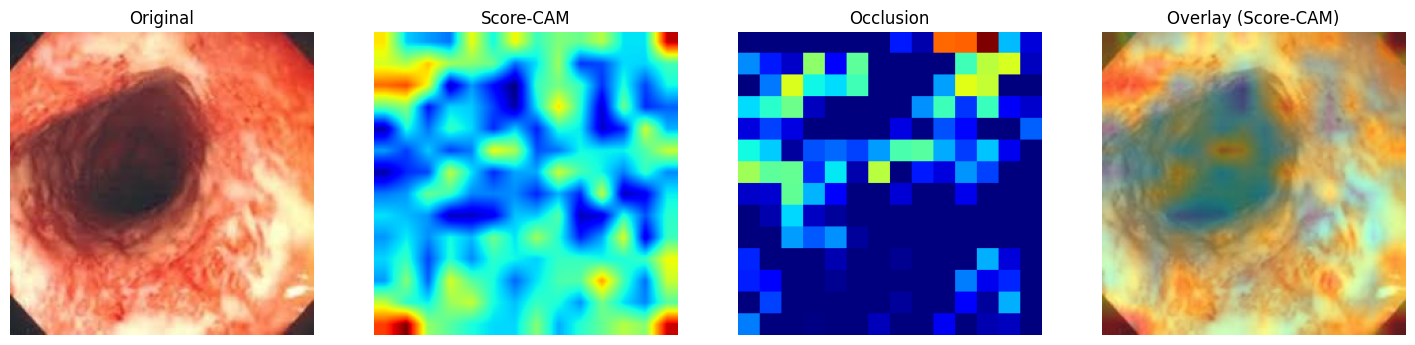

In [3]:
# =========================================================
# EFFResNet-ViT : MEDICAL-GRADE XAI (Score-CAM + Occlusion)
# =========================================================
# ✔ Primary XAI: Score-CAM (gradient-free, stable)
# ✔ Secondary XAI: Occlusion Sensitivity (clinically intuitive)
# ✔ Includes prediction + confidence
# ✔ Designed for hybrid CNN + ViT medical models

# -------------------- CELL 1: IMPORTS --------------------
import os
import torch
import timm
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn as nn
from torchvision import transforms
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224

# -------------------- CELL 2: CLASS NAMES --------------------
CLASS_NAMES = [
    'Normal',
    'Ulcerative Colitis',
    'Polyps',
    'Esophagitis'
]

# -------------------- CELL 3: MODEL DEFINITION --------------------
class EFFResNetViT(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.eff = timm.create_model('efficientnet_b4', pretrained=False, features_only=True)
        self.res = timm.create_model('resnet50', pretrained=False, features_only=True)

        eff_dim = self.eff.feature_info[-1]['num_chs']
        res_dim = self.res.feature_info[-1]['num_chs']

        self.fusion = nn.Conv2d(eff_dim + res_dim, 768, kernel_size=1)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=768, nhead=12, dim_feedforward=3072,
            dropout=0.2, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)

        self.classifier = nn.Sequential(
            nn.LayerNorm(768),
            nn.Dropout(0.4),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        eff = self.eff(x)[-1]
        res = self.res(x)[-1]
        fused = torch.cat([eff, res], dim=1)
        tokens = self.fusion(fused)
        tokens = tokens.flatten(2).transpose(1,2)
        tokens = self.transformer(tokens)
        pooled = tokens.mean(dim=1)
        return self.classifier(pooled)

# -------------------- CELL 4: LOAD TRAINED MODEL --------------------
model = EFFResNetViT(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load('best_effresnetvit.pth', map_location=DEVICE))
model.eval()
print('✓ Model loaded')

# -------------------- CELL 5: IMAGE PREPROCESS --------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD)
])

def load_image(path):
    img = Image.open(path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    return img, tensor

# -------------------- CELL 6: SCORE-CAM IMPLEMENTATION --------------------
class ScoreCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        target_layer.register_forward_hook(self._hook)

    def _hook(self, module, inp, out):
        self.activations = out.detach()

    def generate(self, x, class_idx, max_maps=32):
        self.model.eval()
        _ = self.model(x)
        maps = self.activations[0]
        maps = torch.relu(maps)

        scores = []
        for i in range(min(max_maps, maps.shape[0])):
            m = maps[i]
            m = (m - m.min()) / (m.max() - m.min() + 1e-8)
            m_up = cv2.resize(m.cpu().numpy(), (IMG_SIZE, IMG_SIZE))
            m_tensor = torch.from_numpy(m_up).float().to(DEVICE)
            masked = x * m_tensor.unsqueeze(0).unsqueeze(0)

            with torch.no_grad():
                score = torch.softmax(self.model(masked), dim=1)[0, class_idx]
            scores.append(score.item() * m_up)

        cam = np.sum(scores, axis=0)
        cam = cam / (cam.max() + 1e-8)
        return cam

# -------------------- CELL 7: OCCLUSION SENSITIVITY --------------------
def occlusion_map(model, x, class_idx, patch=32, stride=16):
    base = torch.softmax(model(x), dim=1)[0, class_idx].item()
    heat = np.zeros((IMG_SIZE, IMG_SIZE))

    for y in range(0, IMG_SIZE, stride):
        for z in range(0, IMG_SIZE, stride):
            occluded = x.clone()
            occluded[:,:,y:y+patch, z:z+patch] = 0
            with torch.no_grad():
                score = torch.softmax(model(occluded), dim=1)[0, class_idx].item()
            heat[y:y+patch, z:z+patch] = base - score

    heat = np.maximum(heat, 0)
    heat = heat / (heat.max() + 1e-8)
    return heat

# -------------------- CELL 8: FULL XAI PIPELINE --------------------
def explain(image_path):
    img, x = load_image(image_path)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0]
        pred = probs.argmax().item()

    print(f'Prediction: {CLASS_NAMES[pred]}')
    print(f'Confidence: {probs[pred]*100:.2f}%')

    # Score-CAM (EfficientNet mid-layer)
    score_cam = ScoreCAM(model, model.eff.blocks[4])
    cam_score = score_cam.generate(x, pred)

    # Occlusion
    cam_occ = occlusion_map(model, x, pred)

    # Visualization
    img_np = np.array(img.resize((IMG_SIZE, IMG_SIZE)))

    heat_score = cv2.applyColorMap(np.uint8(255*cam_score), cv2.COLORMAP_JET)
    heat_occ = cv2.applyColorMap(np.uint8(255*cam_occ), cv2.COLORMAP_JET)

    heat_score = cv2.cvtColor(heat_score, cv2.COLOR_BGR2RGB)
    heat_occ = cv2.cvtColor(heat_occ, cv2.COLOR_BGR2RGB)

    overlay_score = np.uint8(0.65*img_np + 0.35*heat_score)
    overlay_occ = np.uint8(0.65*img_np + 0.35*heat_occ)

    plt.figure(figsize=(18,5))
    plt.subplot(1,4,1); plt.imshow(img_np); plt.title('Original'); plt.axis('off')
    plt.subplot(1,4,2); plt.imshow(cam_score, cmap='jet'); plt.title('Score-CAM'); plt.axis('off')
    plt.subplot(1,4,3); plt.imshow(cam_occ, cmap='jet'); plt.title('Occlusion'); plt.axis('off')
    plt.subplot(1,4,4); plt.imshow(overlay_score); plt.title('Overlay (Score-CAM)'); plt.axis('off')
    plt.show()

# -------------------- CELL 9: RUN --------------------
# Example:
explain(r"C:\Users\ADMIN\Desktop\download.jpg")

